(590540, 433)
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


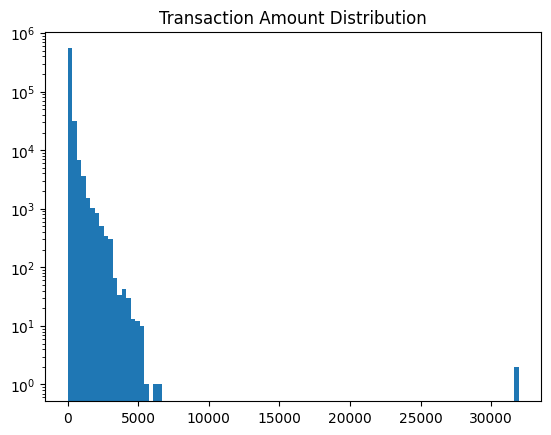

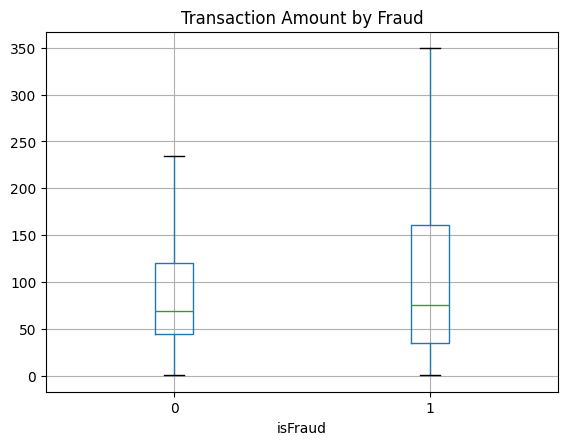

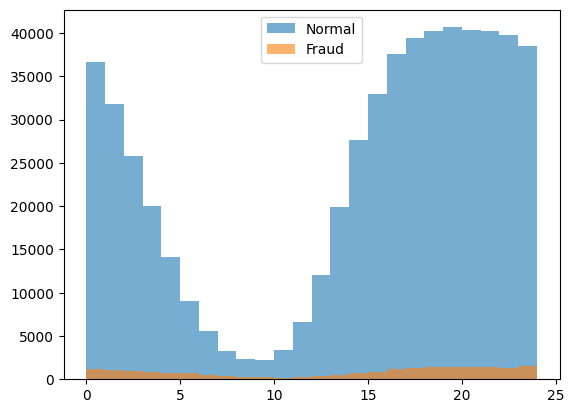

Saved eda_enriched_data.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/initial_cleaned_data.csv")
print(df.shape)

# Fraud rate
print(df["isFraud"].value_counts(normalize=True))

# Transaction amount distribution
plt.hist(df["TransactionAmt"], bins=100)
plt.yscale("log")
plt.title("Transaction Amount Distribution")
plt.show()

# Amount vs fraud
df.boxplot(column="TransactionAmt", by="isFraud", showfliers=False)
plt.title("Transaction Amount by Fraud")
plt.suptitle("")
plt.show()

# Time-based behaviour
df["TransactionHour"] = (df["TransactionDT"] / 3600) % 24
plt.hist(df[df["isFraud"]==0]["TransactionHour"], bins=24, alpha=0.6, label="Normal")
plt.hist(df[df["isFraud"]==1]["TransactionHour"], bins=24, alpha=0.6, label="Fraud")
plt.legend()
plt.show()

# Save enriched data
df.to_csv("../data/processed/eda_enriched_data.csv", index=False)
print("Saved eda_enriched_data.csv")